# `JIDT` — Java Information Dynamics Toolkit (via JPype)

> **Docs**: https://github.com/jlizier/jidt

**JIDT** is a Java library that provides a wide suite of estimators for information-theoretic measures on time series.
We access it from Python via **JPype**, which starts a JVM (Java Virtual Machine) inside the Python process.

### Estimators available
| Estimator | Use case |
|-----------|----------|
| **KSG** (Kraskov–Stögbauer–Grassberger) | Nonparametric, works on continuous data |
| **Gaussian** | Analytic, fast, assumes linear-Gaussian dynamics |
| **Discrete** | Plugin estimator for integer-valued series |

### What we compute
| Measure | Class |
|---------|-------|
| Transfer Entropy (KSG) | `TransferEntropyCalculatorKraskov` |
| Transfer Entropy (Gaussian) | `TransferEntropyCalculatorGaussian` |
| Active Information Storage (KSG) | `ActiveInfoStorageCalculatorKraskov` |


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_wine
from sklearn.feature_selection import mutual_info_classif

import jpype
import jpype.imports
import os
import idtxl  # used to locate bundled infodynamics.jar

SEED = 42
rng = np.random.default_rng(SEED)
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
print("Imports OK.")


Imports OK.


## 1. Start the JVM

JIDT requires a running JVM. We start it once per Python session using the `infodynamics.jar` bundled with `idtxl`.


In [2]:
jidt_jar = os.path.join(os.path.dirname(idtxl.__file__), 'infodynamics.jar')
assert os.path.exists(jidt_jar), f"JAR not found at {jidt_jar}"

if not jpype.isJVMStarted():
    jpype.startJVM(classpath=[jidt_jar])
    print(f"JVM started.  JAR: {jidt_jar}")
else:
    print("JVM already running.")


JVM started.  JAR: c:\Users\User\.conda\envs\mithic-jidt\Lib\site-packages\idtxl\infodynamics.jar


## 2. Construct a Causal Time Series

We build a simple binary process where $Y$ is mostly autoregressive but occasionally
copies $X$'s previous state, creating a genuine $X \to Y$ link.

$$
Y_t = \begin{cases}
Y_{t-1} & \text{with prob. } p_{\mathrm{self}} = 0.9 \\
X_{t-1} & \text{otherwise}
\end{cases}
$$

In [5]:
T = 500

# X: independent fair coin (no memory, no causal source)
x = rng.integers(0, 2, size=T)

# Y: autoregressive + driven by X
y = np.zeros(T, dtype=int)
y[0] = rng.integers(0, 2)
p_self = 0.9

for t in range(1, T):
    if rng.random() < p_self:
        y[t] = y[t-1]        # keep own state
    else:
        y[t] = x[t-1]        # copy X

x_f = x.astype(float)
y_f = y.astype(float)
print(f"Series length: {T}")
print(f"X sample: {x[:20].tolist()}")
print(f"Y sample: {y[:20].tolist()}")
print(f"\nTrue causal structure: X → Y")


Series length: 500
X sample: [1, 1, 0, 0, 0, 1, 0, 1, 0, 1, 1, 0, 0, 1, 0, 0, 1, 0, 0, 0]
Y sample: [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1]

True causal structure: X → Y


## 3. KSG Transfer Entropy

The KSG estimator is **nonparametric** — it uses $k$ nearest neighbours to estimate the conditional MI.
JIDT returns results in **nats** (1 nat = $1/\ln 2$ bits).


In [8]:
TeCalcKSG = jpype.JClass(
    "infodynamics.measures.continuous.kraskov.TransferEntropyCalculatorKraskov"
)

def jidt_ksg_te(source, target, k=1, knn=4):
    """KSG Transfer Entropy (source → target). Returns nats."""
    calc = TeCalcKSG()
    calc.setProperty("k", str(knn))
    calc.initialise(k)
    src_java = jpype.JArray(jpype.JDouble)(source.tolist())
    tgt_java = jpype.JArray(jpype.JDouble)(target.tolist())
    calc.setObservations(src_java, tgt_java)
    return float(calc.computeAverageLocalOfObservations())

te_ksg_xy = jidt_ksg_te(x_f, y_f)
te_ksg_yx = jidt_ksg_te(y_f, x_f)

nats2bits = 1.0 / np.log(2)
print("JIDT KSG Transfer Entropy")
print(f"  TE(X→Y) = {te_ksg_xy:.4f} nats  = {te_ksg_xy*nats2bits:.4f} bits   ← HIGH ✓")
print(f"  TE(Y→X) = {te_ksg_yx:.4f} nats  = {te_ksg_yx*nats2bits:.4f} bits   ← LOW  ✓")

JIDT KSG Transfer Entropy
  TE(X→Y) = 0.0640 nats  = 0.0924 bits   ← HIGH ✓
  TE(Y→X) = 0.0199 nats  = 0.0287 bits   ← LOW  ✓


## 4. Gaussian Transfer Entropy

The Gaussian estimator assumes linear dynamics — it is faster and exact under that assumption.


In [9]:
TeCalcGauss = jpype.JClass(
    "infodynamics.measures.continuous.gaussian.TransferEntropyCalculatorGaussian"
)

def jidt_gauss_te(source, target, k=1):
    """Gaussian Transfer Entropy (source → target). Returns nats."""
    calc = TeCalcGauss()
    calc.initialise(k)
    src_java = jpype.JArray(jpype.JDouble)(source.tolist())
    tgt_java = jpype.JArray(jpype.JDouble)(target.tolist())
    calc.setObservations(src_java, tgt_java)
    return float(calc.computeAverageLocalOfObservations())

te_gauss_xy = jidt_gauss_te(x_f, y_f)
te_gauss_yx = jidt_gauss_te(y_f, x_f)

print("JIDT Gaussian Transfer Entropy")
print(f"  TE(X→Y) = {te_gauss_xy:.4f} nats  = {te_gauss_xy*nats2bits:.4f} bits")
print(f"  TE(Y→X) = {te_gauss_yx:.4f} nats  = {te_gauss_yx*nats2bits:.4f} bits")


JIDT Gaussian Transfer Entropy
  TE(X→Y) = 0.0378 nats  = 0.0545 bits
  TE(Y→X) = 0.0000 nats  = 0.0000 bits


## 5. KSG Active Information Storage

In [10]:
AisCalcKSG = jpype.JClass(
    "infodynamics.measures.continuous.kraskov.ActiveInfoStorageCalculatorKraskov"
)

def jidt_ksg_ais(series, k=1, knn=4):
    """KSG Active Information Storage. Returns nats."""
    calc = AisCalcKSG()
    calc.setProperty("k", str(knn))
    calc.initialise(k)
    arr = jpype.JArray(jpype.JDouble)(series.tolist())
    calc.setObservations(arr)
    return float(calc.computeAverageLocalOfObservations())

ais_x = jidt_ksg_ais(x_f)
ais_y = jidt_ksg_ais(y_f)

print("JIDT KSG Active Information Storage")
print(f"  AIS(X) = {ais_x:.4f} nats  = {ais_x*nats2bits:.4f} bits   ← i.i.d.; low memory")
print(f"  AIS(Y) = {ais_y:.4f} nats  = {ais_y*nats2bits:.4f} bits   ← AR process; high memory")


JIDT KSG Active Information Storage
  AIS(X) = 0.0008 nats  = 0.0012 bits   ← i.i.d.; low memory
  AIS(Y) = 0.3913 nats  = 0.5646 bits   ← AR process; high memory


## 6. Visualisation

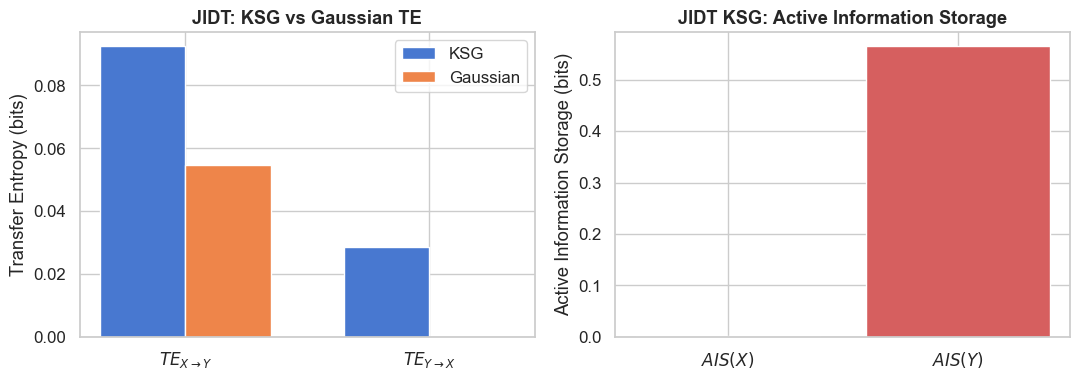

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

# TE comparison: KSG vs Gaussian
labels_te = ['$TE_{X\\to Y}$', '$TE_{Y\\to X}$']
ksg_te = [te_ksg_xy * nats2bits, te_ksg_yx * nats2bits]
gauss_te = [te_gauss_xy * nats2bits, te_gauss_yx * nats2bits]
x_pos = np.arange(2)
w = 0.35
axes[0].bar(x_pos - w/2, ksg_te,   w, label='KSG',     color=sns.color_palette()[0])
axes[0].bar(x_pos + w/2, gauss_te, w, label='Gaussian', color=sns.color_palette()[1])
axes[0].set_xticks(x_pos); axes[0].set_xticklabels(labels_te)
axes[0].set_ylabel('Transfer Entropy (bits)')
axes[0].set_title('JIDT: KSG vs Gaussian TE', fontweight='bold')
axes[0].legend()

# AIS
axes[1].bar(['$AIS(X)$', '$AIS(Y)$'],
            [ais_x * nats2bits, ais_y * nats2bits],
            color=[sns.color_palette()[2], sns.color_palette()[3]])
axes[1].set_ylabel('Active Information Storage (bits)')
axes[1].set_title('JIDT KSG: Active Information Storage', fontweight='bold')

plt.tight_layout()
plt.show()


## 7. Real Data — UCI Wine Dataset

We discretise the top-2 features (by MI with class label) and compute TE in both directions.
We compute KSG TE (continuous, no discretisation needed).
This checks whether the features have a detectable temporal ordering 

> **Note**: the Wine dataset is not a time series, thus the dynamical interpretation is meaningless. Wine samples are not sequential, so any detected links reflect co-variation rather than temporal causality. This is merely an illustrative example to show the application.

In [12]:
wine = load_wine()
X_wine, y_wine = wine.data, wine.target
feature_names = list(wine.feature_names)

mi_scores = mutual_info_classif(X_wine, y_wine, random_state=42)
order = np.argsort(mi_scores)[::-1]
f0, f1 = feature_names[order[0]], feature_names[order[1]]

a = X_wine[:, order[0]].astype(float)
b = X_wine[:, order[1]].astype(float)

te_ab = jidt_ksg_te(a, b)
te_ba = jidt_ksg_te(b, a)
ais_a = jidt_ksg_ais(a)
ais_b = jidt_ksg_ais(b)

print(f"Top-2 features: '{f0}' and '{f1}'")
print(f"\nKSG Transfer Entropy (Wine, samples treated as sequence)")
print(f"  TE({f0[:15]}→{f1[:15]}) = {te_ab*nats2bits:.4f} bits")
print(f"  TE({f1[:15]}→{f0[:15]}) = {te_ba*nats2bits:.4f} bits")
print(f"\nKSG Active Information Storage")
print(f"  AIS({f0[:15]}) = {ais_a*nats2bits:.4f} bits")
print(f"  AIS({f1[:15]}) = {ais_b*nats2bits:.4f} bits")


Top-2 features: 'flavanoids' and 'proline'

KSG Transfer Entropy (Wine, samples treated as sequence)
  TE(flavanoids→proline) = 0.0856 bits
  TE(proline→flavanoids) = 0.0793 bits

KSG Active Information Storage
  AIS(flavanoids) = 0.9345 bits
  AIS(proline) = 0.7105 bits
